# v27 — CNN THUẦN tối ưu ESP-NN (separable k3 + pointwise 1×1 + relu6 + maxpool)

Bỏ LSTM (ESP-NN không tăng tốc recurrent). Mọi op map vào kernel ESP-NN được tăng tốc.

**Dùng lại `cache_resize_64_32` có sẵn — KHÔNG tiền xử lý / windowing lại.**

In [1]:
# === Kích hoạt Keras 2 (legacy) cho TOÀN BỘ notebook ===
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
!pip install -q tf-keras

import shutil

ZIP_PATH  = '/media/data3/users/hungvm/dataset/sisfall/archive.zip'
WORKSPACE = '/media/data3/users/hungvm/dataset/sisfall/workspace'

if not os.path.exists(WORKSPACE):
    os.makedirs(WORKSPACE)
    !unzip -q "{ZIP_PATH}" -d "{WORKSPACE}"
    print("Giải nén hoàn tất!")
else:
    print("Workspace đã tồn tại!")

Workspace đã tồn tại!


# 4. ML Pipeline I/O (DataPreprocessor & OutputReporter)
Đây là 2 class cốt lõi chịu trách nhiệm tổ chức Dataloader, Caching, Split Subject và Report.


In [2]:
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import shutil

class DataPreprocessor:
    def __init__(self, data_dir, cache_dir, class_names):
        self.data_dir = Path(data_dir)
        self.cache_dir = Path(cache_dir)
        self.class_names = class_names
        
        self.TRAIN_SUBJECTS = {f"SA{i:02d}" for i in range(1, 19)} | {f"SE{i:02d}" for i in range(1, 9)}
        self.VAL_SUBJECTS = {f"SA{i:02d}" for i in range(19, 22)} | {f"SE{i:02d}" for i in range(9, 12)}
        self.TEST_SUBJECTS = {f"SA{i:02d}" for i in range(22, 24)} | {f"SE{i:02d}" for i in range(12, 16)}

    def parse_filename_info(self, filename):
        if '_Trans_' in filename: return 'Trans'
        if '_StandSit_' in filename or '_Lie_' in filename: return 'Idle'
        prefix = filename[:3]
        if prefix in ['D01', 'D02', 'D05', 'D06']: return 'Walk'
        if prefix in ['D03', 'D04']: return 'Run'
        if prefix.startswith('F'): return 'Fall'
        return None

    def load_single_csv(self, file_path):
        try:
            filename = file_path.stem
            subject_id = filename.split('_')[1]
            label_str = self.parse_filename_info(filename)
            if label_str is None: return None
            label = self.class_names.index(label_str)
            df = pd.read_csv(file_path)
            if len(df) != 200: return None
            return df.to_numpy(), label, subject_id
        except: return None

    def load_or_create_dataset(self):
        self.cache_dir.mkdir(exist_ok=True, parents=True)
        train_x, train_y = self.cache_dir/'X_train.npy', self.cache_dir/'y_train.npy'
        val_x, val_y = self.cache_dir/'X_val.npy', self.cache_dir/'y_val.npy'
        test_x, test_y = self.cache_dir/'X_test.npy', self.cache_dir/'y_test.npy'
        
        if all(p.exists() for p in [train_x, train_y, val_x, val_y, test_x, test_y]):
            print("[*] Load data từ Cache...")
            return (np.load(train_x), np.load(train_y), np.load(val_x), np.load(val_y), np.load(test_x), np.load(test_y))

        print(f"[*] Đang đọc file CSV từ {self.data_dir}...")
        all_files = list(self.data_dir.rglob('*.csv'))
        
        if len(all_files) == 0:
            raise FileNotFoundError(f"LỖI: Không tìm thấy file CSV nào trong {self.data_dir}. Vui lòng chạy lại Bước 2 (Windowing)!")
            
        X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
        
        with ThreadPoolExecutor(max_workers=8) as executor:
            for res in tqdm(executor.map(self.load_single_csv, all_files), total=len(all_files)):
                if res is None: continue
                data, label, sub = res
                if sub in self.TRAIN_SUBJECTS: X_train.append(data); y_train.append(label)
                elif sub in self.VAL_SUBJECTS: X_val.append(data); y_val.append(label)
                elif sub in self.TEST_SUBJECTS: X_test.append(data); y_test.append(label)
                    
        X_train, y_train = np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.int32)
        X_val, y_val = np.array(X_val, dtype=np.float32), np.array(y_val, dtype=np.int32)
        X_test, y_test = np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.int32)
        
        np.save(train_x, X_train); np.save(train_y, y_train)
        np.save(val_x, X_val); np.save(val_y, y_val)
        np.save(test_x, X_test); np.save(test_y, y_test)
        
        return X_train, y_train, X_val, y_val, X_test, y_test

    def apply_preprocessing(self, X_train, X_val, X_test):
        # Sửa lỗi Index Error: Chỉ cắt mảng nếu mảng thực sự có chứa dữ liệu (3 chiều)
        for X in [X_train, X_val, X_test]:
            if X.ndim == 3 and X.shape[0] > 0:
                X[:, :, 0:3] = np.clip(X[:, :, 0:3], -8.0, 8.0) / 8.0
                X[:, :, 3:6] = X[:, :, 3:6] / 2000.0
        return X_train, X_val, X_test

    def get_balanced_class_weights(self, y_train, class_weight_modifiers=None):
        if len(y_train) == 0: return {}
        vals = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        weights = dict(zip(np.unique(y_train), vals))
        if class_weight_modifiers:
            for cls_name, mod in class_weight_modifiers.items():
                if cls_name in self.class_names:
                    weights[self.class_names.index(cls_name)] *= mod
        return weights

class OutputReporter:
    def __init__(self, out_dir, class_names):
        self.out_dir = Path(out_dir)
        self.out_dir.mkdir(exist_ok=True, parents=True)
        self.class_names = class_names

    def plot_training_history(self, history, version="v_colab"):
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.legend(); plt.title('Accuracy')
        plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.legend(); plt.title('Loss')
        plt.tight_layout(); plt.savefig(self.out_dir / f'history_{version}.png'); plt.show()

    def evaluate_and_report(self, model, X_test, y_test, version="v_colab", fall_threshold=0.25):
        if len(X_test) == 0: return
        fall_idx = self.class_names.index('Fall')
        y_pred_probs = model.predict(X_test, batch_size=256)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_pred[y_pred_probs[:, fall_idx] >= fall_threshold] = fall_idx
        
        report_str = "\n" + "="*50 + "\n"
        report_str += f"BÁO CÁO PHÂN LOẠI TẬP KIỂM THỬ - {version} (Threshold {fall_threshold})\n"
        report_str += "="*50 + "\n"
        
        cls_report = classification_report(y_test, y_pred, target_names=self.class_names, digits=4)
        report_str += cls_report + "\n"
        print(report_str)
        
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8,6))
        plt.imshow(cm, cmap=plt.cm.Blues); plt.colorbar()
        plt.xticks(np.arange(len(self.class_names)), self.class_names, rotation=45)
        plt.yticks(np.arange(len(self.class_names)), self.class_names)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i,j],'d'), ha="center", color="white" if cm[i,j] > cm.max()/2. else "black")
        plt.ylabel('Nhãn Thực Tế')
        plt.xlabel('Nhãn Dự Đoán')
        plt.tight_layout()
        plt.savefig(self.out_dir / f'confusion_matrix_{version}.png')
        plt.show()
        
        true_falls = np.sum(y_test == fall_idx)
        detected_falls = cm[fall_idx, fall_idx]
        recall_fall = (detected_falls / true_falls) * 100 if true_falls > 0 else 0
        
        eval_str = "\n" + "="*50 + "\n"
        eval_str += "KẾT QUẢ ĐÁNH GIÁ CHUYÊN BIỆT LỚP TÉ NGÃ (FALL):\n"
        eval_str += f"  - Số ca ngã thực tế: {true_falls}\n"
        eval_str += f"  - Số ca ngã phát hiện đúng: {detected_falls}\n"
        eval_str += f"  - TỶ LỆ RECALL TÉ NGÃ: {recall_fall:.2f}%\n"
        eval_str += "="*50 + "\n"
        
        print(eval_str)
        report_str += eval_str
        
        with open(self.out_dir / f'report_{version}.txt', 'w', encoding='utf-8') as rf:
            rf.write(report_str)
        print(f"[*] Đã lưu báo cáo tại {self.out_dir / f'report_{version}.txt'}")


I0000 00:00:1781770428.361675  671745 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Kiến trúc — v27 CNN thuần (ESP-NN friendly)

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, SeparableConv1D, BatchNormalization,
                                     Activation, MaxPooling1D, GlobalAveragePooling1D, Dropout, Dense)
from tensorflow.keras.models import Model

def build_model(input_shape=(200, 6), n_classes=5):
    # v27 - CNN THUAN bam tap lenh ESP-NN tang toc:
    #   separable conv (depthwise 6.3x + pointwise 1x1 14.2x) | relu6 11.48x | maxpool 7.83x | FC 7.83x
    #   KHONG LSTM/GRU (ESP-NN khong tang toc recurrent), KHONG SE (sigmoid khong tang toc).
    inp = Input(shape=input_shape)

    # Stem: Conv1D k3 (5.55x), downsample 200->100
    x = Conv1D(24, 3, strides=2, padding='same', use_bias=False)(inp)
    x = BatchNormalization()(x); x = Activation('relu6')(x)

    # Block 1
    x = SeparableConv1D(32, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x); x = Activation('relu6')(x)
    x = MaxPooling1D(2)(x)                       # 100->50

    # Block 2
    x = SeparableConv1D(48, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x); x = Activation('relu6')(x)
    x = MaxPooling1D(2)(x)                       # 50->25

    # Block 3
    x = SeparableConv1D(64, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x); x = Activation('relu6')(x)
    x = MaxPooling1D(2)(x)                       # 25->12

    # Head
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(n_classes, activation='softmax')(x)

    model = Model(inp, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'])
    return model

# 6. Huấn luyện + Đánh giá

[*] Load data từ Cache...
Phân bố nhãn train: {'Walk': 8427, 'Run': 5217, 'Idle': 8365, 'Trans': 5706, 'Fall': 7125}
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 6)]          0         
                                                                 
 conv1d (Conv1D)             (None, 100, 24)           432       
                                                                 
 batch_normalization (Batch  (None, 100, 24)           96        
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 100, 24)           0         
                                                                 
 separable_conv1d (Separabl  (None, 100, 32)           840       
 eConv1D)                                                        
          

I0000 00:00:1781770431.422377  671745 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3915 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1781770433.606570  672356 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781770435.587826  672356 service.cc:153] XLA service 0x7f72c5a05860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781770435.587847  672356 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5 (Driver: 12.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781770435.593879  672356 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781770435.687112  672356 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


545/545 [==============================] - ETA: 0s - loss: 1.0923 - accuracy: 0.7708
Epoch 1: val_loss improved from inf to 1.03064, saving model to /media/data3/users/hungvm/dataset/sisfall/workspace/output_v27/best_model_v27.keras
545/545 [==============================] - 10s 9ms/step - loss: 1.0923 - accuracy: 0.7708 - val_loss: 1.0306 - val_accuracy: 0.7381 - lr: 0.0010
Epoch 2/100
540/545 [============================>.] - ETA: 0s - loss: 0.9261 - accuracy: 0.8516
Epoch 2: val_loss improved from 1.03064 to 0.70099, saving model to /media/data3/users/hungvm/dataset/sisfall/workspace/output_v27/best_model_v27.keras
545/545 [==============================] - 4s 7ms/step - loss: 0.9261 - accuracy: 0.8518 - val_loss: 0.7010 - val_accuracy: 0.8777 - lr: 0.0010
Epoch 3/100
544/545 [============================>.] - ETA: 0s - loss: 0.8930 - accuracy: 0.8668
Epoch 3: val_loss improved from 0.70099 to 0.67328, saving model to /media/data3/users/hungvm/dataset/sisfall/workspace/output_v27/b

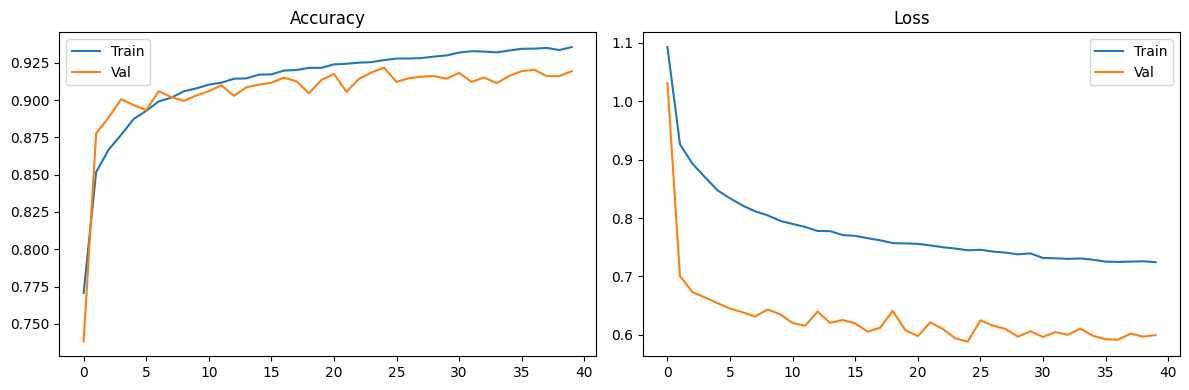

24/24 [==============================] - 0s 5ms/step

BÁO CÁO PHÂN LOẠI TẬP KIỂM THỬ - v27 (Threshold 0.25)
              precision    recall  f1-score   support

        Walk     0.9646    0.9014    0.9319      1906
         Run     0.9791    0.9512    0.9649      1085
        Idle     0.9074    0.8855    0.8963      1982
       Trans     0.5745    0.8463    0.6844       410
        Fall     0.9618    0.9747    0.9682       750

    accuracy                         0.9103      6133
   macro avg     0.8775    0.9118    0.8892      6133
weighted avg     0.9223    0.9103    0.9142      6133




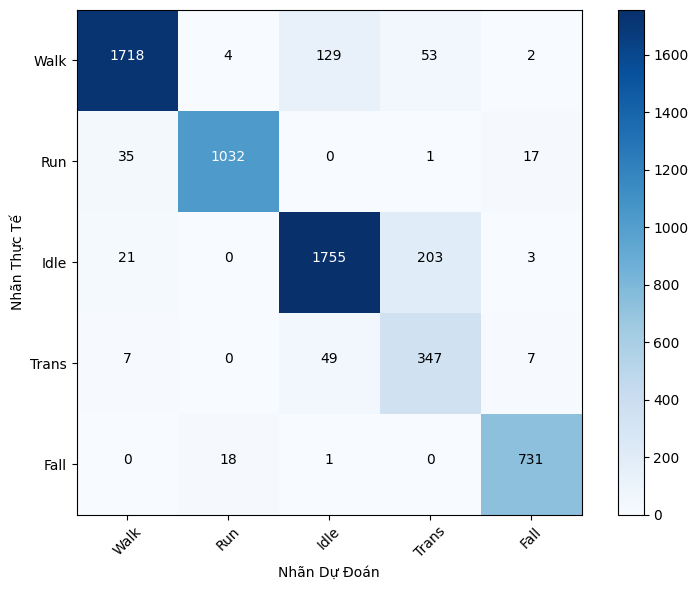


KẾT QUẢ ĐÁNH GIÁ CHUYÊN BIỆT LỚP TÉ NGÃ (FALL):
  - Số ca ngã thực tế: 750
  - Số ca ngã phát hiện đúng: 731
  - TỶ LỆ RECALL TÉ NGÃ: 97.47%

[*] Đã lưu báo cáo tại /media/data3/users/hungvm/dataset/sisfall/workspace/output_v27/report_v27.txt


In [4]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

class FallDetectionTrainerResize(DataPreprocessor, OutputReporter):
    def __init__(self):
        data_dir  = f'{WORKSPACE}/SisFall_dataset_Windowed_new'
        cache_dir = f'{WORKSPACE}/cache_resize_64_32'
        out_dir   = f'{WORKSPACE}/output_v27'
        class_names = ['Walk', 'Run', 'Idle', 'Trans', 'Fall']
        DataPreprocessor.__init__(self, data_dir, cache_dir, class_names)
        OutputReporter.__init__(self, out_dir, class_names)
        self.version = "v27"

trainer = FallDetectionTrainerResize()
checkpoint_path = Path(trainer.out_dir) / f'best_model_{trainer.version}.keras'

# 1. Nạp + tiền xử lý
X_train, y_train, X_val, y_val, X_test, y_test = trainer.load_or_create_dataset()
X_train, X_val, X_test = trainer.apply_preprocessing(X_train, X_val, X_test)
print("Phân bố nhãn train:", {trainer.class_names[k]: int((y_train==k).sum()) for k in range(5)})

# 2. Class weights (đẩy Fall x3)
weight_modifiers = {'Fall': 3.0, 'Trans': 1.0, 'Idle': 1.0}
class_weights = trainer.get_balanced_class_weights(y_train, weight_modifiers)

# 3. One-hot
y_train_oh = to_categorical(y_train, num_classes=5)
y_val_oh = to_categorical(y_val, num_classes=5)

# 4. Build model RESIZE
model = build_model(input_shape=(200, 6), n_classes=5)
model.summary()

# 5. Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint(filepath=str(checkpoint_path), monitor='val_loss', save_best_only=True, verbose=1),
]

# 6. Train
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=100, batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks, verbose=1
)

# 7. Đánh giá
trainer.plot_training_history(history, version=trainer.version)
trainer.evaluate_and_report(model, X_test, y_test, version=trainer.version, fall_threshold=0.25)

# 7. Export INT8 TFLite → `model_data_v1_resize.cc/.h`

In [5]:
# === Export INT8 TFLite + sinh model_data .cc/.h (NHUNG SAN ops cho TFLM wrapper) ===
import numpy as np
ver = trainer.version
out_dir = Path(trainer.out_dir)

np.random.seed(42)
rep_idx = np.random.choice(len(X_train), size=min(300, len(X_train)), replace=False)
def representative_data_gen():
    for i in rep_idx:
        yield [X_train[i:i+1].astype(np.float32)]

static_in = tf.keras.Input(batch_shape=(1, 200, 6), dtype='float32')
static_model = tf.keras.models.clone_model(model, input_tensors=static_in)
static_model.set_weights(model.get_weights())

converter = tf.lite.TFLiteConverter.from_keras_model(static_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

tflite_path = out_dir / f'model_{ver}_int8.tflite'
tflite_path.write_bytes(tflite_model)
print(f"[*] Saved {tflite_path}  ({len(tflite_model)} bytes)")

it = tf.lite.Interpreter(model_content=tflite_model); it.allocate_tensors()
inp = it.get_input_details()[0]; outp = it.get_output_details()[0]
all_ops = sorted({d['op_name'] for d in it._get_ops_details()})
NON_REG = {'DELEGATE', 'CALL_ONCE', 'CUSTOM'}
reg_ops = [o for o in all_ops if o not in NON_REG]
in_scale, in_zp = inp['quantization']; out_scale, out_zp = outp['quantization']
in_len = int(np.prod(inp['shape'])); out_len = int(np.prod(outp['shape']))
print("[*] Input :", inp['shape'], inp['dtype'])
print("[*] Output:", outp['shape'], outp['dtype'])
print("[*] Ops can dang ky:", reg_ops)

OP2ADD = {
    'CONV_2D':'AddConv2D','DEPTHWISE_CONV_2D':'AddDepthwiseConv2D','MAX_POOL_2D':'AddMaxPool2D',
    'AVERAGE_POOL_2D':'AddAveragePool2D','MEAN':'AddMean','FULLY_CONNECTED':'AddFullyConnected',
    'SOFTMAX':'AddSoftmax','LOGISTIC':'AddLogistic','RELU6':'AddRelu6','RESHAPE':'AddReshape',
    'ADD':'AddAdd','MUL':'AddMul','CONCATENATION':'AddConcatenation','PAD':'AddPad',
    'QUANTIZE':'AddQuantize','DEQUANTIZE':'AddDequantize','STRIDED_SLICE':'AddStridedSlice',
    'UNIDIRECTIONAL_SEQUENCE_LSTM':'AddUnidirectionalSequenceLSTM',
}
res_lines = []
for o in reg_ops:
    m = OP2ADD.get(o)
    res_lines.append(f"//   resolver.{m}();" if m else f"//   /* op '{o}': tu tra cuu Add method */")

meta = (
    "// ============================================================\n"
    f"// AUTO-GENERATED model data  --  {ver}\n"
    f"// TFLite INT8 size : {len(tflite_model)} bytes\n"
    "// ------------------------------------------------------------\n"
    f"// Input  : shape={list(inp['shape'])} dtype={inp['dtype'].__name__} quant(scale={in_scale:.8g}, zero_point={in_zp})\n"
    f"// Output : shape={list(outp['shape'])} dtype={outp['dtype'].__name__} quant(scale={out_scale:.8g}, zero_point={out_zp})\n"
    "// INT8<->real:  q = round(real/scale)+zero_point ; real = (q-zero_point)*scale\n"
    "// ------------------------------------------------------------\n"
    f"// OPS cua mang ({len(reg_ops)}) -- dang ky DUNG nhung op nay:\n"
    + "".join(f"//   - {o}\n" for o in reg_ops)
    + (f"// (Bo qua pseudo-op: {', '.join(o for o in all_ops if o in NON_REG)})\n" if any(o in NON_REG for o in all_ops) else "")
    + "//\n"
    f"// GOI Y MicroMutableOpResolver (so op = {len(reg_ops)}):\n"
    f"//   static tflite::MicroMutableOpResolver<{len(reg_ops)}> resolver;\n"
    + "".join(l + "\n" for l in res_lines)
    + "// ============================================================\n"
)

body, line = '', '  '
for i, b in enumerate(tflite_model):
    line += f'0x{b:02x}, '
    if (i+1) % 12 == 0:
        body += line.rstrip() + '\n'; line = '  '
if line.strip():
    body += line.rstrip()
body = body.rstrip(', \n')

cc = (meta + '#include "model_data.h"\n\n'
      f'const unsigned char g_model_data[] alignas(16) = {{\n{body}\n}};\n\n'
      f'const unsigned int g_model_data_len = {len(tflite_model)};\n')
(out_dir / f'model_data_{ver}.cc').write_text(cc, encoding='utf-8')

h = (meta + "#ifndef MODEL_DATA_H_\n#define MODEL_DATA_H_\n\n"
     f"#define MODEL_INPUT_LEN   {in_len}\n#define MODEL_OUTPUT_LEN  {out_len}\n#define MODEL_NUM_OPS     {len(reg_ops)}\n\n"
     '#ifdef __cplusplus\nextern "C" {\n#endif\n\n'
     "extern const unsigned char g_model_data[];\nextern const unsigned int g_model_data_len;\n\n"
     "#ifdef __cplusplus\n}\n#endif\n\n#endif  // MODEL_DATA_H_\n")
(out_dir / f'model_data_{ver}.h').write_text(h, encoding='utf-8')
print(f"[*] Da sinh model_data_{ver}.cc / .h")


INFO:tensorflow:Assets written to: /tmp/tmp7on3khgp/assets


INFO:tensorflow:Assets written to: /tmp/tmp7on3khgp/assets


[*] Saved /media/data3/users/hungvm/dataset/sisfall/workspace/output_v27/model_v27_int8.tflite  (24128 bytes)
[*] Input : [  1 200   6] <class 'numpy.int8'>
[*] Output: [1 5] <class 'numpy.int8'>
[*] Ops can dang ky: ['CONV_2D', 'DEPTHWISE_CONV_2D', 'FULLY_CONNECTED', 'MAX_POOL_2D', 'MEAN', 'RESHAPE', 'SOFTMAX']
[*] Da sinh model_data_v27.cc / .h


/media/data3/users/hungvm/anaconda3/envs/har_fall/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1781770605.935227  671745 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781770605.935249  671745 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781770605.935518  671745 reader.cc:83] Reading SavedModel from: /tmp/tmp7on3khgp
I0000 00:00:1781770605.938291  671745 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781770605.938307  671745 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp7on3khgp
I0000 00:00:1781770605.947954  671745 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1781770605.950383  671745 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781770605.984920  671745 loader.cc:220] Running init